## Preparation

Now we have a closer look at the results, specifically how confident Alphafold 2 is in its predictions! First we need some python modules. Execute the cell below to load them into the notebook!


In [ ]:
import pickle
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from colabfold.plot import plot_msa_v2

Now we need to find the output files we need:

In [2]:
# working directory
ALPHAFOLD_WORKING_DIR = Path.cwd() / "alphafold2"

# inference output directory
ALPHAFOLD_RESULTS_DIR = ALPHAFOLD_WORKING_DIR / "output"

INPUT_FASTA = ALPHAFOLD_WORKING_DIR / "insulin.fasta"
project_name = INPUT_FASTA.stem
project_output = ALPHAFOLD_RESULTS_DIR / project_name

First we look at the coverage of the multi-sequence alignment (MSA):

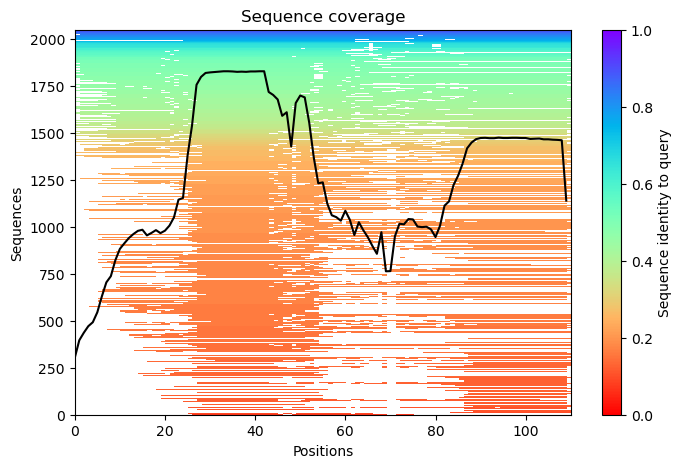

In [3]:
pkl_file = project_output / "features.pkl"
with open(pkl_file, "rb") as f:
    features = pickle.load(f)

plot = plot_msa_v2(features)
plt.savefig(ALPHAFOLD_RESULTS_DIR / str(project_name + "_sequence_coverage.png"))
plt.show()

Now we need to extract data on the ptm, iptm and pae from the results file.

In [4]:
data = []

for file in project_output.glob("result*.pkl"):
    with open(file, "rb") as f:
        results = pickle.load(f)
        data.append(
            {
                "file": file,
                "ptm": results["ptm"],
                "iptm": results["iptm"],
                "ranking_confidence": results["ranking_confidence"],
                "plddt": results["plddt"],
                "pae": results["predicted_aligned_error"],
            }
        )
# summarize & clean
df = pd.DataFrame(data)
df["ptm"] = df["ptm"].astype(float)
df["iptm"] = df["iptm"].astype(float)
# sort by confidence to look at best model
df_sorted = df.sort_values(by="ranking_confidence", ascending=False).reset_index(
    drop=True
)
best_name = str(df_sorted.iloc[0]["file"]).split("/")[-1].strip(".pkl")
print(f"Best model: {best_name}")

Best model: result_model_5_multimer_v3_pred_2


We can plot the PAE to show the global confidence level in amino acid position. You can choose between Alphafold 3 colors (green/white) or AlphaFold 2 colab colors (red/blue).

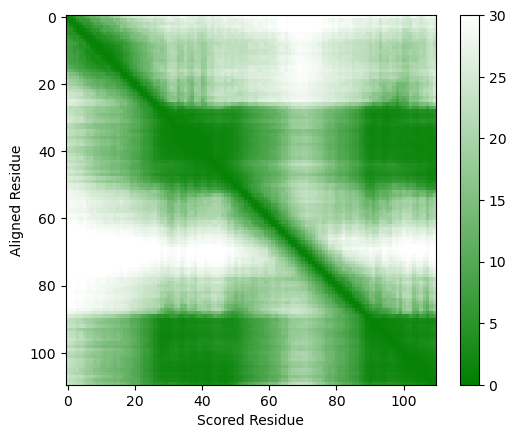

In [5]:
## Choose the colormap for either AlphaFold3 (green to white)
# AlphaFold 3
cmap = LinearSegmentedColormap.from_list("custom", ["green", "white"])
# AlphaFold 2
# cmap = 'bwr'

plt.imshow(df_sorted.iloc[0]["pae"], cmap=cmap, vmin=0, vmax=30)
plt.colorbar()
plt.xlabel("Scored Residue")
plt.ylabel("Aligned Residue")

plt.margins(0)

plt.savefig(ALPHAFOLD_RESULTS_DIR / f"{project_name}_{best_name}_PAE.png")

plt.show()

Next we plot the pLDDT per residue. This shows us differences in the local confidence in the 3D structure.

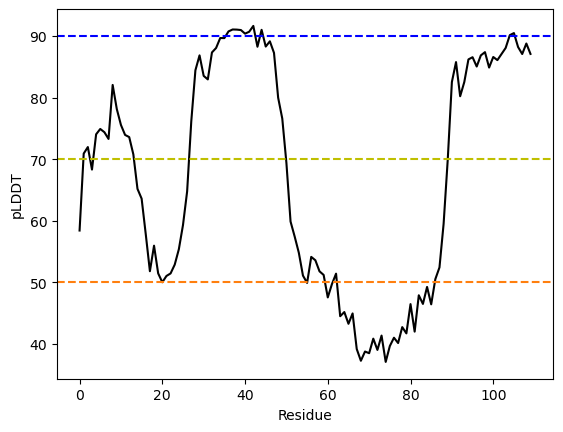

In [6]:
plt.plot(df_sorted.iloc[0]["plddt"], color="black")

plt.axhline(y=90, color="b", linestyle="--")
plt.axhline(y=70, color="y", linestyle="--")
plt.axhline(y=50, color="tab:orange", linestyle="--")

plt.xlabel("Residue")
plt.ylabel("pLDDT")

plt.savefig(ALPHAFOLD_RESULTS_DIR / f"{project_name}_{best_name}_pLDDT.png")

plt.show()